In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 
import matplotlib as mpl


mpl.rcParams["font.family"] = "serif"
mpl.rcParams["mathtext.fontset"] = "stix"
mpl.rcParams["axes.unicode_minus"] = False


In [2]:
import pandas as pd
import re
import io

# --- Procesamiento de chi2_log.csv ---

# Cargar el archivo chi2_log.csv
chi2_path = r'c:\Proyectos\Astro\AEspectra\exp 0\Retreival Tests\chi2_log_finale.csv'
chi2_df = pd.read_csv(chi2_path)

# Función para extraer la información de la columna model_name
def parse_model_name(model_name):
    n_transits_match = re.search(r'(\d+)T', model_name)
    n_transits = int(n_transits_match.group(1)) if n_transits_match else None

    model_type_match = re.search(r'(contam|recon|uncontam)', model_name)
    model_type = model_type_match.group(1) if model_type_match else None

    spot_fraction_match = re.search(r'(\d+\.\d+)spot', model_name)
    spot_fraction = float(spot_fraction_match.group(1)) if spot_fraction_match else 0.0

    facula_fraction_match = re.search(r'(\d+\.\d+)fac', model_name)
    facula_fraction = float(facula_fraction_match.group(1)) if facula_fraction_match else 0.0

    return n_transits, model_type, spot_fraction, facula_fraction

# Aplicar la función para crear las nuevas columnas
chi2_df[['n_transits', 'model_type', 'spot_fraction', 'facula_fraction']] = chi2_df['model_name'].apply(lambda x: pd.Series(parse_model_name(x)))


# --- Procesamiento de Times ---

# Cargar el archivo Times
times_path = r'c:\Proyectos\Astro\AEspectra\exp 0\Retreival Tests\Times_de_verdad'
times_df = pd.read_csv(times_path, sep='\s+', engine='python')

# Limpiar las comillas de la columna Mode
times_df['Mode'] = times_df['Mode'].str.replace('"', '')

# Función para extraer facula y spot de la columna ffacfspot
def parse_ffacfspot(ffacfspot):
    parts = ffacfspot.split('-')
    facula_fraction = float(parts[0])
    spot_fraction = float(parts[1])
    return facula_fraction, spot_fraction

# Aplicar la función para crear las nuevas columnas
times_df[['facula_fraction', 'spot_fraction']] = times_df['ffacfspot'].apply(lambda x: pd.Series(parse_ffacfspot(x)))

# Renombrar columnas para la fusión
times_df = times_df.rename(columns={'N_T': 'n_transits', 'Mode': 'model_type', 'Time': 'retrieval_time_min'})

# Eliminar la columna original que ya no es necesaria
times_df = times_df.drop(columns=['ffacfspot'])


# --- Fusión de los DataFrames ---

# Fusionar los dos dataframes
merged_df = pd.merge(chi2_df, times_df, on=['n_transits', 'model_type', 'spot_fraction', 'facula_fraction'], how='left')

# Mostrar el resultado
print("DataFrame combinado:")
print(merged_df.head())

# Puedes guardar el dataframe a un csv si quieres
# merged_df.to_csv('c:/Proyectos/Astro/AEspectra/exp 0/Retreival Tests/retrieval_results.csv', index=False)

DataFrame combinado:
   planet_name                   model_name  dof         chi2  chi2_reduced  \
0  Trappist-1e   recon_10T_0.08spot-0.54fac  374   140.481671      0.375619   
1  Trappist-1e   recon_10T_0.26spot-0.70fac  374   131.115889      0.350577   
2  Trappist-1e   recon_10T_0.01spot-0.08fac  374   133.372519      0.356611   
3  Trappist-1e   recon_10T_0.00spot-0.00fac  374   130.982987      0.350222   
4  Trappist-1e  recon_100T_0.00spot-0.00fac  374  1267.056967      3.387853   

     N   p           MSE  n_transits model_type  spot_fraction  \
0  385  11  3.565349e-10          10      recon           0.08   
1  385  11  3.308338e-10          10      recon           0.26   
2  385  11  3.449145e-10          10      recon           0.01   
3  385  11  3.296390e-10          10      recon           0.00   
4  385  11  3.208474e-10         100      recon           0.00   

   facula_fraction  retrieval_time_min  
0             0.54                9.53  
1             0.70       

<>:35: SyntaxWarning: invalid escape sequence '\s'
<>:35: SyntaxWarning: invalid escape sequence '\s'
C:\Users\User\AppData\Local\Temp\ipykernel_36880\3273613239.py:35: SyntaxWarning: invalid escape sequence '\s'
  times_df = pd.read_csv(times_path, sep='\s+', engine='python')


In [3]:
merged_df

,planet_name,model_name,dof,chi2,chi2_reduced,N,p,MSE,n_transits,model_type,spot_fraction,facula_fraction,retrieval_time_min
0,Trappist-1e,recon_10T_0.08spot-0.54fac,374,140.481671,0.375619,385,11,3.565349e-10,10,recon,0.08,0.54,9.53
1,Trappist-1e,recon_10T_0.26spot-0.70fac,374,131.115889,0.350577,385,11,3.308338e-10,10,recon,0.26,0.70,10.23
2,Trappist-1e,recon_10T_0.01spot-0.08fac,374,133.372519,0.356611,385,11,3.449145e-10,10,recon,0.01,0.08,9.23
3,Trappist-1e,recon_10T_0.00spot-0.00fac,374,130.982987,0.350222,385,11,3.296390e-10,10,recon,0.00,0.00,9.89
4,Trappist-1e,recon_100T_0.00spot-0.00fac,374,1267.056967,3.387853,385,11,3.208474e-10,100,recon,0.00,0.00,20.18
5,Trappist-1e,recon_100T_0.01spot-0.08fac,374,1275.080914,3.409307,385,11,3.226797e-10,100,recon,0.01,0.08,17.52
6,Trappist-1e,recon_100T_0.08spot-0.54fac,374,1269.288400,3.393819,385,11,3.209525e-10,100,recon,0.08,0.54,14.45
7,Trappist-1e,recon_100T_0.26spot-0.70fac,374,1272.164717,3.401510,385,11,3.296839e-10,100,recon,0.26,0.70,15.48
8,Trappist-1e,contam_10T_0.00spot-0.00fac,374,38.385128,0.102634,385,11,4.210409e-10,10,contam,0.00,0.00,29.65
9,Trappist-1e,contam_10T_0.01spot-0.08fac,374,57.897739,0.154807,385,11,4.758216e-10,10,contam,0.01,0.08,41.57


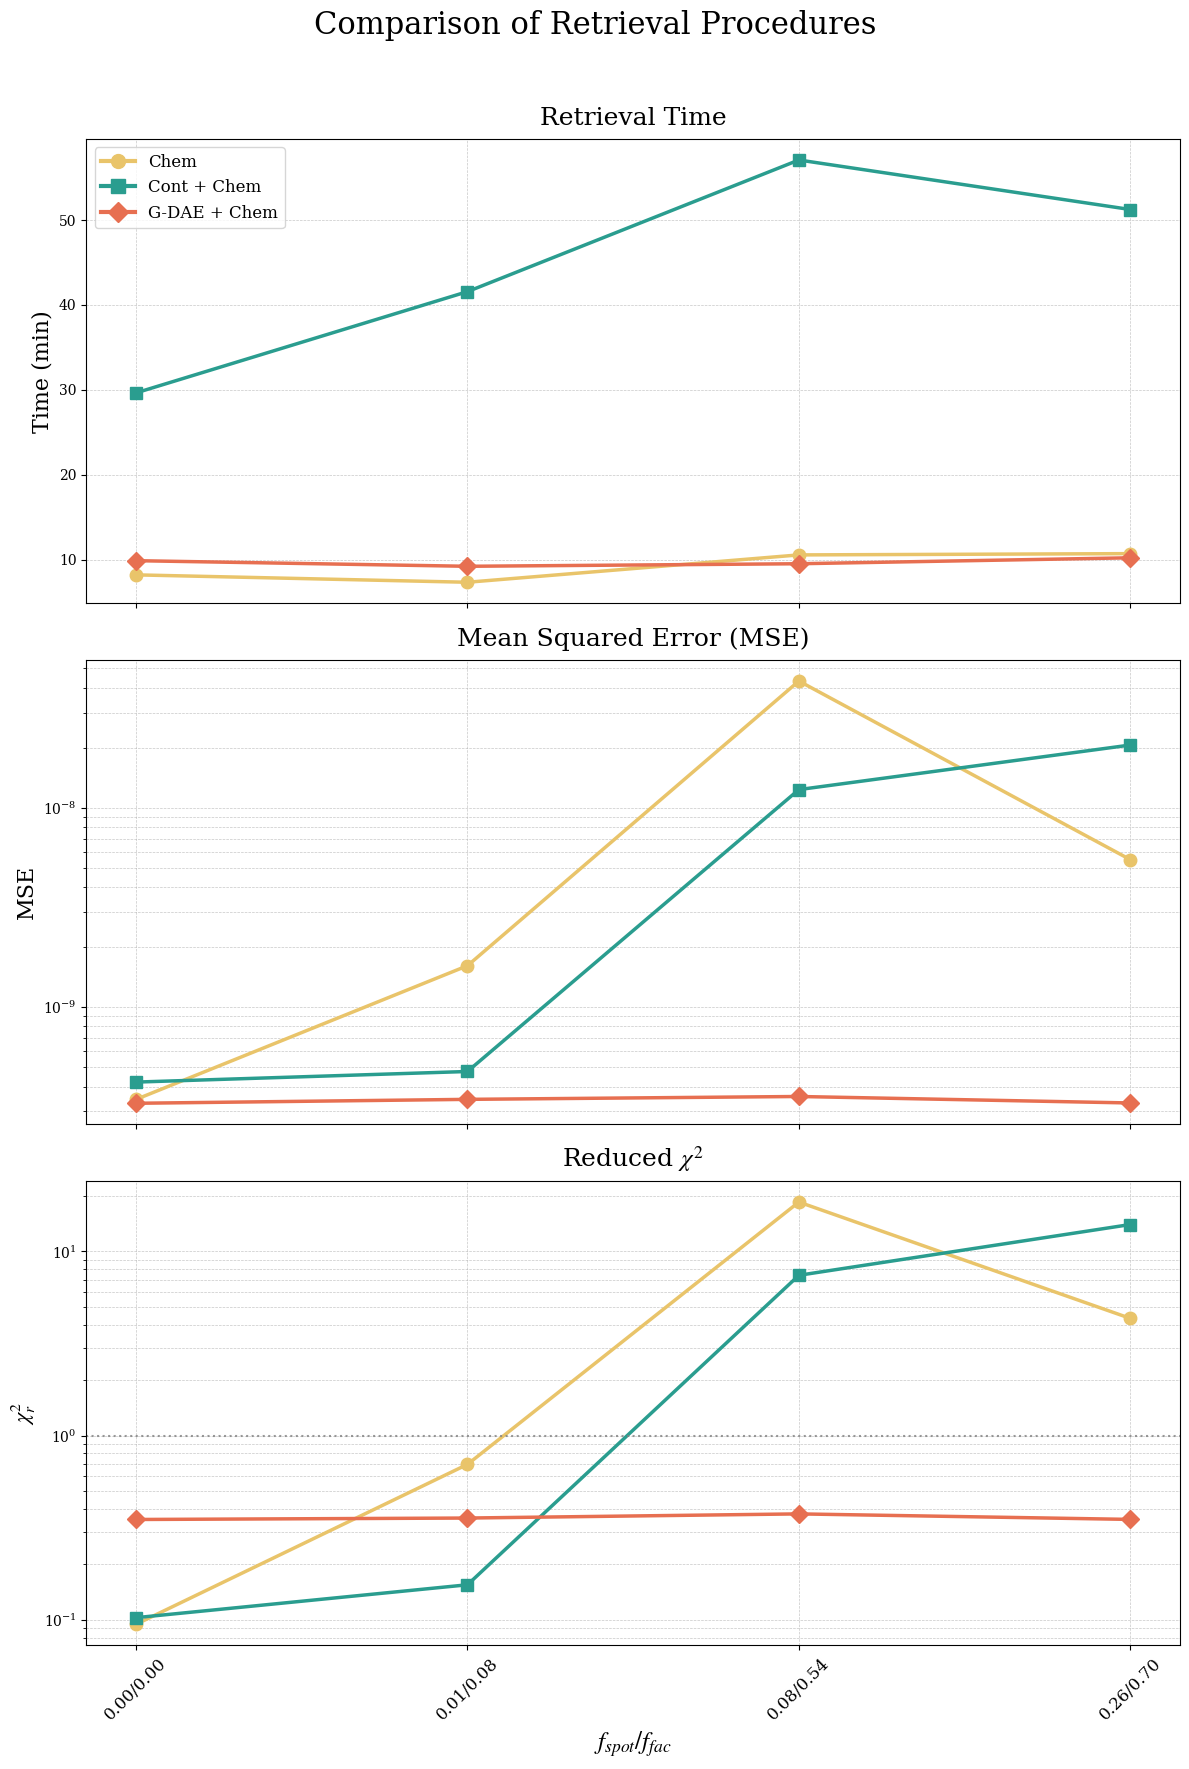

In [5]:
# --- Plotting: Retrieval Comparison (Time, MSE, Chi2) ---
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# Paleta de colores
PALETTE = {
    "uncontam": "#E9C46A",  # Amarillo (Chem)
    "contam":   "#2A9D8F",  # Verde azulado (Cont + Chem)
    "recon":    "#E76F51",  # Rojo/Naranja (G-DAE + Chem)
}

# Figura geométrica por modelo (Distintas para cada uno)
MARKERS = {
    "uncontam": "o",  # Círculo
    "contam":   "s",  # Cuadrado (Square)
    "recon":    "D",  # Rombo (Diamond)
}

# Leyendas simplificadas
LEGEND_LABELS = {
    "uncontam": "Chem",
    "contam":   "Cont + Chem",
    "recon":    "G-DAE + Chem",
}

# --- PREPARACIÓN DE DATOS ---

# Etiqueta x formateada con 2 decimales
def frac_label(row):
    return f"{row['spot_fraction']:.2f}/{row['facula_fraction']:.2f}"

# Aseguramos que la columna x_label exista
# (Asumiendo que merged_df ya existe en tu entorno)
merged_df["x_label"] = merged_df.apply(frac_label, axis=1)

# Ordenamos las etiquetas del eje X
x_labels = sorted(
    list(merged_df["x_label"].unique()),
    key=lambda x: (float(x.split("/")[0]), float(x.split("/")[1])),
)
x_ticks = np.arange(len(x_labels))

# --- GRAFICACIÓN ---

# Figuras: 3 subplots verticales
fig, axes = plt.subplots(3, 1, figsize=(12, 18), sharex=True)
fig.suptitle("Comparison of Retrieval Procedures", fontsize=22)

model_order = ["uncontam", "contam", "recon"]

# Parámetros de estilo visual
LINE_WIDTH = 2.5   # Grosor de la línea
MARKER_SIZE = 9    # Tamaño de la figura geométrica

for model_type in model_order:
    m = MARKERS[model_type]
    color = PALETTE[model_type]
    
    # Filtramos por modelo
    model_df = merged_df[merged_df["model_type"] == model_type]

    # --- 10 TRÁNSITOS (Línea Sólida) ---
    sub_10 = model_df[model_df["n_transits"] == 10]
    
    if not sub_10.empty:
        df_10t = (sub_10.groupby("x_label")[["retrieval_time_min", "MSE", "chi2_reduced"]]
                  .mean()
                  .reindex(x_labels)
                  .reset_index())
        
        # Solo graficar si hay datos
        if not df_10t["retrieval_time_min"].isnull().all():
            # Plot Time
            axes[0].plot(x_ticks, df_10t["retrieval_time_min"], 
                         color=color, linestyle="-", marker=m, 
                         linewidth=LINE_WIDTH, markersize=MARKER_SIZE)
            # Plot MSE
            axes[1].plot(x_ticks, df_10t["MSE"],                
                         color=color, linestyle="-", marker=m, 
                         linewidth=LINE_WIDTH, markersize=MARKER_SIZE)
            # Plot Chi2
            axes[2].plot(x_ticks, df_10t["chi2_reduced"],       
                         color=color, linestyle="-", marker=m, 
                         linewidth=LINE_WIDTH, markersize=MARKER_SIZE)

    """ 
    # --- 100 TRÁNSITOS (Línea Punteada) - OPCIONAL ---
    # Si descomentas esto, heredará el mismo grosor y tamaño
    sub_100 = model_df[model_df["n_transits"] == 100]
    if not sub_100.empty:
        df_100t = (sub_100.groupby("x_label")[["retrieval_time_min", "MSE", "chi2_reduced"]]
                    .mean().reindex(x_labels).reset_index())
        
        if not df_100t["retrieval_time_min"].isnull().all():
            axes[0].plot(x_ticks, df_100t["retrieval_time_min"], color=color, linestyle="--", marker=m, linewidth=LINE_WIDTH, markersize=MARKER_SIZE)
            axes[1].plot(x_ticks, df_100t["MSE"],                color=color, linestyle="--", marker=m, linewidth=LINE_WIDTH, markersize=MARKER_SIZE)
            axes[2].plot(x_ticks, df_100t["chi2_reduced"],       color=color, linestyle="--", marker=m, linewidth=LINE_WIDTH, markersize=MARKER_SIZE)
    """

# --- CONFIGURACIÓN DE EJES Y ESTÉTICA ---

# Subplot 0: Time
axes[0].set_ylabel("Time (min)", fontsize=16)
axes[0].set_title("Retrieval Time", pad=10, fontsize=18)
axes[0].grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.7)

# Subplot 1: MSE
axes[1].set_ylabel("MSE", fontsize=16)
axes[1].set_title("Mean Squared Error (MSE)", pad=10, fontsize=18)
axes[1].set_yscale("log")
axes[1].grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.7)

# Subplot 2: Chi2
axes[2].set_ylabel(r"$\chi^2_r$", fontsize=16)
axes[2].set_title(r"Reduced $\chi^2$", fontsize=18, pad=10)
axes[2].set_yscale("log")
axes[2].grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.7)

# Línea de referencia en chi^2_r = 1
axes[2].axhline(1.0, color="gray", lw=1.5, ls=":", alpha=0.8)

# Eje X global
plt.xlabel(r"$f_{spot} / f_{fac}$", fontsize=18)
plt.xticks(ticks=x_ticks, labels=x_labels, rotation=45, fontsize=12)

# Crear Leyenda Personalizada (Más grande y clara)
legend_elements = [
    Line2D([0], [0], 
           color=PALETTE[mt], 
           lw=3,                    # Grosor en leyenda
           marker=MARKERS[mt], 
           markersize=10,           # Tamaño figura en leyenda
           label=LEGEND_LABELS[mt])
    for mt in model_order
]

# Colocar leyenda en el primer gráfico
axes[0].legend(handles=legend_elements, fontsize=12, loc="upper left")

plt.tight_layout(rect=[0, 0, 1, 0.96])

# Guardar y mostrar
plt.savefig("retrieval_comparison_improved.png", dpi=300, bbox_inches="tight")
plt.show()

## Recuperaciones

In [6]:
# === Parser POSEIDON: valor recuperado + 1σ min/max (sin best-fit), robusto a codificación/encabezado ===
import re
from pathlib import Path
from typing import Dict, List, Optional
import pandas as pd
import numpy as np

# Patrón numérico robusto (incluye notación científica)
NUM = r'[-+]?(?:\d+(?:\.\d*)?|\.\d+)(?:[eE][-+]?\d+)?'

# Ejemplo de nombre de modelo: "contam_10T_0.00spot-0.00fac"
MODEL_REGEX = re.compile(
    r'^(?P<model_type>contam|recon|uncontam)_(?P<n_transits>\d+)T_(?P<spot_fraction>\d+(?:\.\d+)?)spot-(?P<facula_fraction>\d+(?:\.\d+)?)fac$'
)

# Línea típica dentro del bloque 1σ: "log_CO2 = -2.32 (+0.23)(-0.26)"
PARAM_LINE_1SIGMA = re.compile(
    rf'^\s*log_(?P<gas>H2O|CH4|CO2|O3)\s*=\s*(?P<val>{NUM})\s*\(\+(?P<plus>{NUM})\)\s*\(\-(?P<minus>{NUM})\)\s*$'
)

def read_text_safely(path: Path) -> str:
    """Intenta UTF-8, luego UTF-8 con BOM, luego Latin-1 (evita problemas con 'σ')."""
    for enc in ("utf-8", "utf-8-sig", "latin-1"):
        try:
            return path.read_text(encoding=enc)
        except Exception:
            continue
    return path.read_bytes().decode("latin-1", errors="ignore")

def parse_model_block(text: str) -> Dict[str, object]:
    """Extrae la línea 'Model:' y parsea el nombre del modelo si sigue el patrón estándar."""
    model_line = None
    for line in text.splitlines():
        if line.strip().startswith("Model:"):
            model_line = line.split("Model:", 1)[1].strip()
            break
    out: Dict[str, object] = {"model_name": model_line}
    if model_line:
        m = MODEL_REGEX.match(model_line)
        if m:
            out.update({
                "model_type": m.group("model_type"),
                "n_transits": int(m.group("n_transits")),
                "spot_fraction": float(m.group("spot_fraction")),
                "facula_fraction": float(m.group("facula_fraction")),
            })
        else:
            out.update({
                "model_type": None, "n_transits": np.nan,
                "spot_fraction": np.nan, "facula_fraction": np.nan,
            })
    else:
        out.update({
            "model_type": None, "n_transits": np.nan,
            "spot_fraction": np.nan, "facula_fraction": np.nan,
        })
    return out

def find_block_lines_1sigma(text: str) -> List[str]:
    """
    Detecta el bloque de '1 σ constraints' SIN depender del carácter 'σ'.
    Busca una línea que empiece con '1' y contenga 'constraints' (insensible a mayúsculas),
    luego salta separadores/vacías hasta la primera línea con '=' y recolecta parámetros.
    """
    lines = text.splitlines()
    start_idx = None
    # No usamos \b tras el 1 para evitar depender de 'σ'; aceptamos cualquier cosa hasta 'constraints'
    pat = re.compile(r'^\s*1[^\n]*constraints\b', flags=re.IGNORECASE)
    for i, line in enumerate(lines):
        if pat.search(line):
            start_idx = i
            break
    if start_idx is None:
        return []
    i = start_idx + 1
    # Avanza hasta la primera línea "paramétrica" (contiene '='), saltando **** y líneas en blanco
    while i < len(lines) and "=" not in lines[i]:
        i += 1
    collected = []
    while i < len(lines):
        s = lines[i].strip()
        # Cortamos si vuelve a aparecer un separador o una línea vacía (fin del bloque)
        if (not s) or s.startswith("***") or s.startswith("###") or s.startswith("---") or s.startswith("___"):
            break
        collected.append(s)
        i += 1
    return collected

def parse_params_from_lines(lines: List[str]) -> Dict[str, Dict[str, float]]:
    out: Dict[str, Dict[str, float]] = {}
    for line in lines:
        m = PARAM_LINE_1SIGMA.match(line)
        if not m:
            continue
        gas   = m.group("gas")
        val   = float(m.group("val"))
        plus  = float(m.group("plus"))
        minus = float(m.group("minus"))
        out[gas] = {"val": val, "min1s": val - minus, "max1s": val + plus}
    return out

def fallback_parse_smallest_uncertainty(text: str) -> Dict[str, Dict[str, float]]:
    """
    Plan B: si no se encontró el bloque 1σ (por encabezado raro/codificación),
    escanea TODO el archivo por líneas 'log_* = v (+a)(-b)' y, para cada gas,
    elige la entrada con (a+b) mínimo (aprox. la mejor 1σ).
    """
    out: Dict[str, Dict[str, float]] = {}
    best_errsum: Dict[str, float] = {}
    for raw in text.splitlines():
        m = PARAM_LINE_1SIGMA.match(raw.strip())
        if not m:
            continue
        gas   = m.group("gas")
        val   = float(m.group("val"))
        plus  = float(m.group("plus"))
        minus = float(m.group("minus"))
        errsum = abs(plus) + abs(minus)
        if (gas not in best_errsum) or (errsum < best_errsum[gas]):
            best_errsum[gas] = errsum
            out[gas] = {"val": val, "min1s": val - minus, "max1s": val + plus}
    return out

def parse_poseidon_file(path: Path) -> Dict[str, object]:
    text = read_text_safely(path)
    meta = parse_model_block(text)

    # 1) Intento estándar: bloque 1σ
    block_lines = find_block_lines_1sigma(text)
    one_sigma = parse_params_from_lines(block_lines)

    # 2) Fallback si está vacío: escaneo global por líneas log_*
    if not one_sigma:
        one_sigma = fallback_parse_smallest_uncertainty(text)

    row: Dict[str, object] = {"file": str(path)}
    row.update(meta)

    for gas in ["CO2", "CH4", "O3", "H2O"]:
        g = one_sigma.get(gas, {})
        row[f"log_{gas}"]        = g.get("val",   np.nan)
        row[f"log_{gas}_min1s"]  = g.get("min1s", np.nan)
        row[f"log_{gas}_max1s"]  = g.get("max1s", np.nan)
    return row

def collect_poseidon_results_recovered_minmax(base_dir: Path) -> pd.DataFrame:
    """
    Recorre recursivamente base_dir y procesa todos los '*_results.txt'.
    Devuelve un DataFrame con meta (modelo) + log_CO2/CH4/O3/H2O y sus min1s/max1s (1σ).
    """
    files = sorted(base_dir.rglob("*_results.txt"))
    rows = [parse_poseidon_file(p) for p in files]
    df = pd.DataFrame(rows)

    # Orden de columnas
    meta_cols = ["file", "model_name", "model_type", "n_transits", "spot_fraction", "facula_fraction"]
    gas_cols = []
    for gas in ["CO2", "CH4", "O3", "H2O"]:
        gas_cols += [f"log_{gas}", f"log_{gas}_min1s", f"log_{gas}_max1s"]

    ordered = [c for c in meta_cols if c in df.columns] + [c for c in gas_cols if c in df.columns]
    others  = [c for c in df.columns if c not in ordered]
    df = df[ordered + others]

    # Tipos agradables (n_transits permite NaN -> Int64)
    if "n_transits" in df.columns:
        try:
            df["n_transits"] = df["n_transits"].astype("Int64")
        except Exception:
            pass
    for col in ["spot_fraction", "facula_fraction"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    return df


In [7]:
# === Ejecuta el colector sobre tu carpeta local ===
from pathlib import Path

# Cambia esta ruta por la tuya (raw string para Windows)
BASE_DIR = Path(r"POSEIDON_output\Trappist-1e\retrievals")

df = collect_poseidon_results_recovered_minmax(BASE_DIR)

# Guarda el CSV junto a tus resultados
OUT_CSV = BASE_DIR / "retrieved_gases_recovered_minmax.csv"
df.to_csv(OUT_CSV, index=False)

print(f"Archivos procesados: {len(df)} filas")
print(f"CSV guardado en: {OUT_CSV}")
print()
print(df.head(12).to_string(index=False))


Archivos procesados: 33 filas
CSV guardado en: POSEIDON_output\Trappist-1e\retrievals\retrieved_gases_recovered_minmax.csv

                                                                                   file                   model_name model_type  n_transits  spot_fraction  facula_fraction  log_CO2  log_CO2_min1s  log_CO2_max1s  log_CH4  log_CH4_min1s  log_CH4_max1s  log_O3  log_O3_min1s  log_O3_max1s  log_H2O  log_H2O_min1s  log_H2O_max1s
POSEIDON_output\Trappist-1e\retrievals\results\contam_100T_0.00spot-0.00fac_results.txt contam_100T_0.00spot-0.00fac     contam         100           0.00             0.00    -2.57          -2.67          -2.47    -7.22          -7.44          -7.04   -7.61         -7.88         -7.26    -7.20          -7.64          -6.80
POSEIDON_output\Trappist-1e\retrievals\results\contam_100T_0.01spot-0.08fac_results.txt contam_100T_0.01spot-0.08fac     contam         100           0.01             0.08    -2.77          -2.87          -2.67    -7.04       

In [8]:
#delete rows with NaN values
df = df.dropna()



df[df['model_type'] == 'uncontam']


,file,model_name,model_type,n_transits,spot_fraction,facula_fraction,log_CO2,log_CO2_min1s,log_CO2_max1s,log_CH4,log_CH4_min1s,log_CH4_max1s,log_O3,log_O3_min1s,log_O3_max1s,log_H2O,log_H2O_min1s,log_H2O_max1s
25,POSEIDON_output\Trappist-1e\retrievals\results...,uncontam_100T_0.00spot-0.00fac,uncontam,100,0.00,0.00,-2.80,-2.90,-2.70,-7.37,-7.60,-7.18,-7.71,-7.91,-7.42,-7.38,-7.76,-7.01
26,POSEIDON_output\Trappist-1e\retrievals\results...,uncontam_100T_0.01spot-0.08fac,uncontam,100,0.01,0.08,-2.90,-3.03,-2.76,-7.45,-7.78,-7.17,-7.79,-7.94,-7.53,-7.95,-7.99,-7.88
27,POSEIDON_output\Trappist-1e\retrievals\results...,uncontam_100T_0.08spot-0.54fac,uncontam,100,0.08,0.54,-4.93,-4.98,-4.85,-1.00,-1.00,-1.00,-7.39,-7.75,-7.08,-7.86,-7.95,-7.69
28,POSEIDON_output\Trappist-1e\retrievals\results...,uncontam_100T_0.26spot-0.70fac,uncontam,100,0.26,0.70,-4.99,-5.00,-4.98,-1.00,-1.00,-1.00,-7.94,-7.99,-7.85,-7.93,-7.98,-7.82
29,POSEIDON_output\Trappist-1e\retrievals\results...,uncontam_10T_0.00spot-0.00fac,uncontam,10,0.00,0.00,-2.82,-3.17,-2.47,-7.20,-7.68,-6.77,-7.14,-7.73,-6.47,-6.48,-7.27,-5.91
30,POSEIDON_output\Trappist-1e\retrievals\results...,uncontam_10T_0.01spot-0.08fac,uncontam,10,0.01,0.08,-2.84,-3.53,-2.21,-7.43,-7.79,-6.94,-6.83,-7.53,-6.27,-7.58,-7.87,-7.09
31,POSEIDON_output\Trappist-1e\retrievals\results...,uncontam_10T_0.08spot-0.54fac,uncontam,10,0.08,0.54,-4.72,-4.91,-4.37,-1.02,-1.05,-1.01,-6.88,-7.50,-6.32,-7.46,-7.83,-6.87
32,POSEIDON_output\Trappist-1e\retrievals\results...,uncontam_10T_0.26spot-0.70fac,uncontam,10,0.26,0.70,-4.91,-4.97,-4.80,-1.01,-1.03,-1.00,-7.63,-7.86,-7.30,-7.62,-7.85,-7.31


In [9]:
df

,file,model_name,model_type,n_transits,spot_fraction,facula_fraction,log_CO2,log_CO2_min1s,log_CO2_max1s,log_CH4,log_CH4_min1s,log_CH4_max1s,log_O3,log_O3_min1s,log_O3_max1s,log_H2O,log_H2O_min1s,log_H2O_max1s
0,POSEIDON_output\Trappist-1e\retrievals\results...,contam_100T_0.00spot-0.00fac,contam,100,0.00,0.00,-2.57,-2.67,-2.47,-7.22,-7.44,-7.04,-7.61,-7.88,-7.26,-7.20,-7.64,-6.80
1,POSEIDON_output\Trappist-1e\retrievals\results...,contam_100T_0.01spot-0.08fac,contam,100,0.01,0.08,-2.77,-2.87,-2.67,-7.04,-7.23,-6.88,-7.62,-7.87,-7.26,-7.86,-7.96,-7.69
2,POSEIDON_output\Trappist-1e\retrievals\results...,contam_100T_0.08spot-0.54fac,contam,100,0.08,0.54,-4.06,-4.14,-3.97,-6.27,-6.35,-6.19,-6.96,-7.29,-6.70,-7.97,-7.99,-7.93
3,POSEIDON_output\Trappist-1e\retrievals\results...,contam_100T_0.26spot-0.70fac,contam,100,0.26,0.70,-2.23,-2.30,-2.16,-4.84,-4.89,-4.79,-2.26,-2.34,-2.18,-7.70,-7.91,-7.36
4,POSEIDON_output\Trappist-1e\retrievals\results...,contam_10T_0.00spot-0.00fac,contam,10,0.00,0.00,-2.13,-2.46,-1.82,-7.55,-7.86,-7.13,-7.41,-7.82,-6.88,-6.89,-7.60,-6.24
5,POSEIDON_output\Trappist-1e\retrievals\results...,contam_10T_0.01spot-0.08fac,contam,10,0.01,0.08,-2.84,-3.28,-2.40,-7.49,-7.83,-7.06,-6.25,-7.07,-5.70,-7.07,-7.67,-6.35
6,POSEIDON_output\Trappist-1e\retrievals\results...,contam_10T_0.08spot-0.54fac,contam,10,0.08,0.54,-4.09,-4.40,-3.75,-6.19,-6.47,-5.97,-6.08,-6.85,-5.56,-7.83,-7.95,-7.60
7,POSEIDON_output\Trappist-1e\retrievals\results...,contam_10T_0.26spot-0.70fac,contam,10,0.26,0.70,-2.32,-2.58,-2.09,-4.69,-4.84,-4.55,-2.45,-2.70,-2.19,-7.45,-7.84,-6.87
9,POSEIDON_output\Trappist-1e\retrievals\results...,recon_100T_0.00spot-0.00fac,recon,100,0.00,0.00,-2.64,-2.71,-2.56,-7.40,-7.52,-7.29,-7.83,-7.95,-7.62,-7.38,-7.69,-7.12
10,POSEIDON_output\Trappist-1e\retrievals\results...,recon_100T_0.01spot-0.08fac,recon,100,0.01,0.08,-2.64,-2.71,-2.57,-7.39,-7.51,-7.28,-7.83,-7.95,-7.62,-7.37,-7.67,-7.12


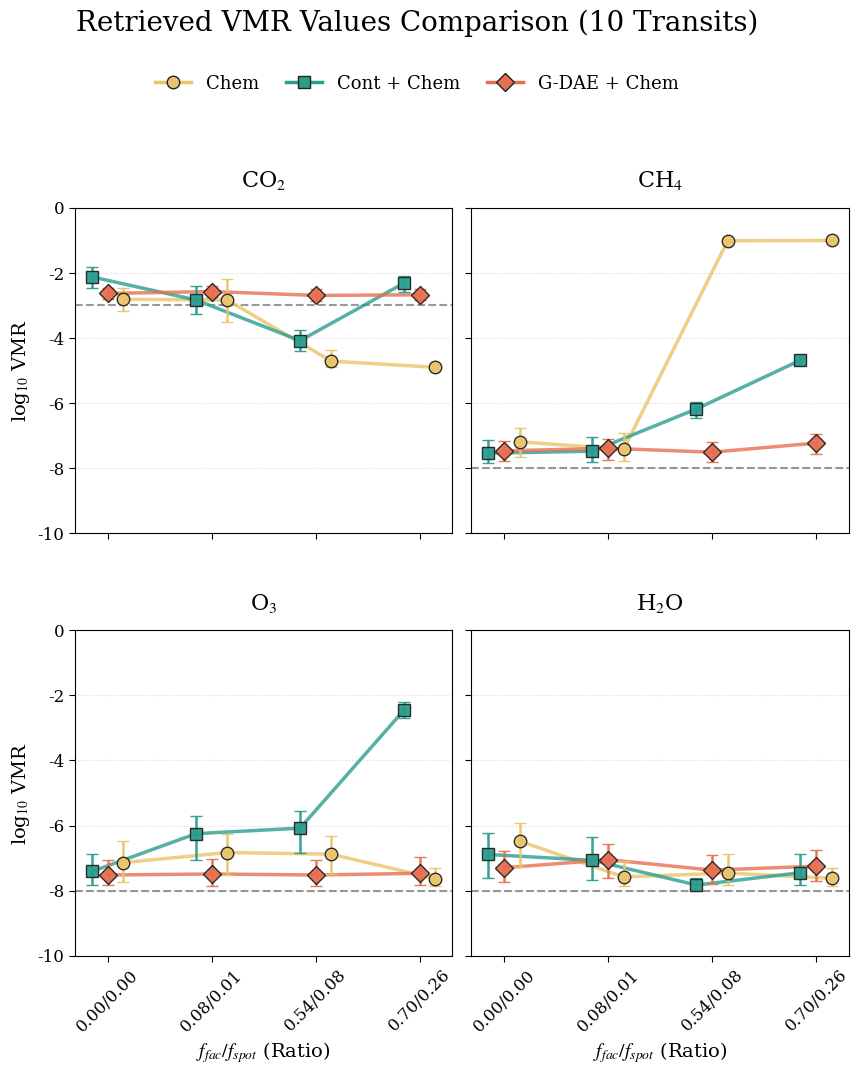

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D

# ==========================================
# === 1. CONFIGURACIÓN DE ESTILO ===
# ==========================================
mpl.rcParams["font.family"] = "serif"
mpl.rcParams["mathtext.fontset"] = "stix"
mpl.rcParams["axes.unicode_minus"] = False

# Parámetros visuales
LINE_WIDTH = 2.5       # Grosor de las líneas
MARKER_SIZE = 9        # Tamaño de los marcadores
EDGE_COLOR = "#222222" # Borde oscuro para los marcadores
ERROR_BAR_WIDTH = 1.8  # Grosor de las barras de error

# Paleta de colores
PALETTE = {
    "uncontam": "#E9C46A",  # Amarillo
    "contam":   "#2A9D8F",  # Verde azulado
    "recon":    "#E76F51",  # Rojo/Naranja
}

# Formas geométricas por modelo
MARKERS = {
    "uncontam": "o",  # Círculo
    "contam":   "s",  # Cuadrado
    "recon":    "D",  # Rombo
}

# Etiquetas
LEGEND_LABELS = {
    "uncontam": "Chem",
    "contam":   "Cont + Chem",
    "recon":    "G-DAE + Chem",
}

# Desplazamientos para evitar solapamiento (jitter horizontal)
FAM_OFFSETS = {"contam": -0.15, "recon": 0.0, "uncontam": +0.15}

# Valores de referencia (Ground Truth)
EXPECTED = {"CO2": -3.0, "CH4": -8.0, "O3": -8.0, "H2O": -8.0}

# ==========================================
# === 2. PREPARACIÓN DE DATOS (SOLO 10T) ===
# ==========================================
# Asumimos que tu dataframe original se llama 'df' o 'merged_df'
# Si se llama 'merged_df', descomenta la siguiente línea:
# df = merged_df.copy()

# Filtramos SOLO 10 tránsitos
plot_df = df[df["n_transits"] == 10].copy()

if plot_df.empty:
    print("¡ALERTA! El DataFrame filtrado está vacío. Revisa tus datos.")

# Crear etiquetas X formateadas
plot_df["ratio"] = (
    plot_df["facula_fraction"].map(lambda v: f"{v:.2f}") + "/" +
    plot_df["spot_fraction"].map(lambda v: f"{v:.2f}")
)
# Ordenar eje X
order = sorted(plot_df["ratio"].astype(str).unique())
_pos_map = {lab: i for i, lab in enumerate(order)}
plot_df["xpos"] = plot_df["ratio"].map(_pos_map)

# ==========================================
# === 3. FUNCIÓN DE PLOTEO ===
# ==========================================
def plot_gas(ax, gas, data):
    y     = f"log_{gas}"
    y_min = f"log_{gas}_min1s"
    y_max = f"log_{gas}_max1s"

    # Referencia (Línea punteada)
    ax.axhline(EXPECTED[gas], linestyle="--", linewidth=1.5, color="#555", alpha=0.6, zorder=1)

    # Si no hay datos de esa molécula, terminamos
    gdf = data[np.isfinite(data[y])] if y in data.columns else pd.DataFrame()
    if gdf.empty:
        ax.set_xticks(range(len(order)))
        ax.set_xticklabels(order)
        return

    # Grid de fondo
    ax.set_axisbelow(True)
    ax.grid(True, which="major", axis="y", alpha=0.5, linestyle=":", linewidth=0.8)

    # Iterar por modelo en orden específico
    model_order = ["uncontam", "contam", "recon"]
    
    for fam in model_order:
        sub = gdf[gdf["model_type"] == fam]
        if sub.empty: continue

        color  = PALETTE.get(fam, "#555")
        marker = MARKERS.get(fam, 'o')

        # Ordenar por eje X
        sub_sorted = sub.sort_values("xpos")
        x = sub_sorted["xpos"].values + FAM_OFFSETS.get(fam, 0.0)
        yv = sub_sorted[y].values

        # Errores
        if y_min in sub_sorted.columns and y_max in sub_sorted.columns:
            yerr_low = yv - sub_sorted[y_min].values
            yerr_up  = sub_sorted[y_max].values - yv
            yerr = np.vstack([yerr_low, yerr_up])
        else:
            yerr = np.zeros((2, len(yv)))

        # 1. Trazar líneas (Conectoras)
        if len(x) > 1:
            ax.plot(
                x, yv,
                linestyle="-",
                linewidth=LINE_WIDTH, 
                color=color, alpha=0.8, zorder=2
            )

        # 2. Trazar Marcadores + Barras de Error
        ax.errorbar(
            x, yv, yerr=yerr,
            fmt=marker,
            ms=MARKER_SIZE,
            capsize=4, capthick=ERROR_BAR_WIDTH*0.8, elinewidth=ERROR_BAR_WIDTH,
            color=color, markerfacecolor=color,
            markeredgecolor=EDGE_COLOR, markeredgewidth=1.0,
            linestyle="None",
            label=LEGEND_LABELS.get(fam, fam),
            alpha=0.95, zorder=3
        )

    ax.set_xticks(range(len(order)))
    ax.set_xticklabels(order, rotation=0, ha="center")

# ==========================================
# === 4. CREACIÓN DE FIGURA Y LAYOUT ===
# ==========================================
fig, axes = plt.subplots(2, 2, figsize=(9, 11), sharex='col', sharey='row')

# --- AQUÍ ESTÁ EL CAMBIO DE ESPACIADO ---
# top=0.80 baja las gráficas, dejando espacio arriba para la leyenda
# hspace=0.30 separa verticalmente los subplots de arriba y abajo
fig.subplots_adjust(top=0.80, bottom=0.12, left=0.12, right=0.98, wspace=0.05, hspace=0.30)

# Título Principal (bien arriba)
fig.suptitle("Retrieved VMR Values Comparison (10 Transits)", fontsize=20, y=0.98)

axes2d = axes
axes_flat = axes.ravel()

# Títulos de las moléculas
gas_titles = {"CO2": r"CO$_2$", "CH4": r"CH$_4$", "O3": r"O$_3$", "H2O": r"H$_2$O"}
gases_to_plot = ["CO2", "CH4", "O3", "H2O"]

for ax, gas in zip(axes_flat, gases_to_plot):
    plot_gas(ax, gas, plot_df)
    # pad=15 aleja el título "CO2" de la gráfica para que respire
    ax.set_title(gas_titles[gas], fontsize=16, pad=15)

# Configuración Ejes Y (Límites y etiquetas)
y_bottom, y_top = -10, 0
y_ticks = np.arange(0, -12, -2)

for i in range(2):
    for j in range(2):
        axes2d[i, j].set_ylim(y_bottom, y_top)
        axes2d[i, j].set_yticks(y_ticks)
        axes2d[i, j].tick_params(labelsize=12, length=4)
        
        # Etiqueta Y solo columna izquierda
        if j == 0:
             axes2d[i, j].set_ylabel(r"log$_{10}$ VMR", fontsize=14)
        
        # Etiqueta X solo fila inferior
        if i == 1:
             axes2d[i, j].set_xlabel(r"$f_{fac}/f_{spot}$ (Ratio)", fontsize=14)
             axes2d[i, j].tick_params(axis='x', rotation=45)

# Manejo fino de visibilidad de ticks
for ax in axes2d[:, 0]: ax.tick_params(axis='y', labelleft=True)
for ax in axes2d[:, 1]: ax.tick_params(axis='y', labelleft=False)
for ax in axes2d[0, :]: ax.tick_params(axis='x', labelbottom=False) 
for ax in axes2d[1, :]: ax.tick_params(axis='x', labelbottom=True)

# ==========================================
# === 5. LEYENDA (Posicionada en el hueco) ===
# ==========================================
present_fams = [fam for fam in ["uncontam", "contam", "recon"] if fam in plot_df["model_type"].unique()]

legend_handles = [
    Line2D([0], [0], 
           marker=MARKERS[f], 
           linestyle='-', linewidth=LINE_WIDTH, 
           color=PALETTE[f], markerfacecolor=PALETTE[f],
           markeredgecolor=EDGE_COLOR, markeredgewidth=1.0, 
           markersize=MARKER_SIZE, 
           label=LEGEND_LABELS[f]) for f in present_fams
]

if legend_handles:
    # bbox_to_anchor=(0.5, 0.89) coloca la leyenda centrada verticalmente
    # en el espacio vacío entre el título principal (0.98) y el inicio de los plots (0.80)
    fig.legend(
        handles=legend_handles,
        loc="lower center", 
        bbox_to_anchor=(0.5, 0.89), 
        ncols=len(legend_handles), 
        frameon=False,
        columnspacing=1.5, handlelength=2.0, fontsize=13
    )

# Guardar
plt.savefig("retrieval_vmr_final_fixed.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# Modificar las últimas 8 filas del DataFrame para cambiar model_type a 'sigma_recon'
if len(merged_df) >= 8:
    merged_df.iloc[-8:, merged_df.columns.get_loc('model_type')] = 'recon'
    print(f"Se modificaron las últimas 8 filas. Total de filas: {len(merged_df)}")
    print("\nÚltimas 10 filas del DataFrame:")
    print(merged_df.tail(10)[['model_type', 'n_transits', 'spot_fraction', 'facula_fraction']])
else:
    print(f"El DataFrame tiene menos de 8 filas ({len(merged_df)} filas). No se puede modificar.")